In [54]:
import matplotlib.pyplot as plt
import numpy as np
import random

from RunSimulator import RunSimulator
from PathPlotter import PathPlotter
master = RunSimulator()

"""
hi indira & tristan & whoever else it concerns
youll have to run this jupyter notebook from beginning prob
tips for jupyter notebook:
1) keep track of what you ran. try NOT to run cells out of order.
2) this may seem easier than normal coding but its actually like not. be careful.
3) fyi ipynbs are 'modified' if code OR cell output changes
"""

"\nhi indira & tristan & whoever else it concerns\nyoull have to run this jupyter notebook from beginning prob\ntips for jupyter notebook:\n1) keep track of what you ran. try NOT to run cells out of order.\n2) this may seem easier than normal coding but its actually like not. be careful.\n3) fyi ipynbs are 'modified' if code OR cell output changes\n"

In [55]:
#baseline constants
baseline_trial_num = 10
error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim=20000
deltahead=2.4

#running trials!
random.seed(42) # NOTE: only set this when you want to RESET the module
master.baseline(baseline_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead)
baseline_final_drifts = master.all_final_drift
baseline_mean_errors = master.all_mean_error
baseline_rmses = master.all_rmse
baseline_errors_over_time = master.all_error_over_time


the mouse moved this far: 324.8378051033331
[[-72.11040188 316.73283626]]
[-72.72942839 291.82497952]
the mouse moved this far: 645.4915509755027
[[-93.12732954 638.73832113]]
[-86.58856339 681.27835915]
the mouse moved this far: 830.8038755403552
[[334.79828485 760.35859177]]
[344.29144416 766.71265978]
the mouse moved this far: 590.563512381621
[[249.7969485  535.13245713]]
[256.57491963 572.09033771]
the mouse moved this far: 305.990081648238
[[223.24507229 209.26434901]]
[227.99111735 197.60919788]
the mouse moved this far: 695.1659687110055
[[618.37083717 317.60546561]]
[637.40521472 307.07121493]
the mouse moved this far: 612.8661508425307
[[-214.45005275 -574.12201989]]
[-229.88260361 -580.03546458]
the mouse moved this far: 1074.768999156258
[[ 327.52475643 1023.64834561]]
[ 356.02767278 1054.05243812]
the mouse moved this far: 372.04076090991634
[[187.47003748 321.35543068]]
[203.27985377 333.87061083]
the mouse moved this far: 423.6262484642674
[[379.17139363 188.91334691]]
[

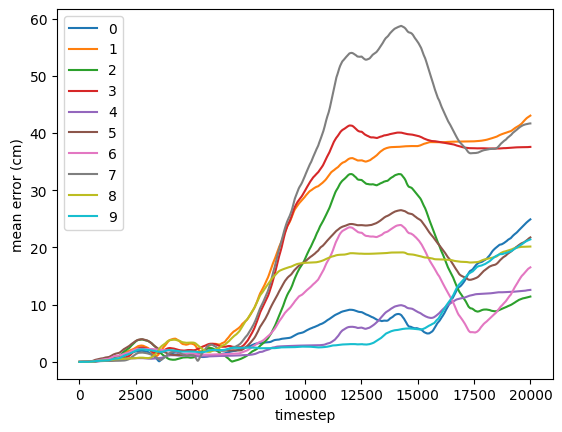

In [56]:
#plot error over time
x = np.arange(sim) # this only works now in this specific case bc error_freq=1
y = np.mean(baseline_errors_over_time, axis=0)
y_list = baseline_errors_over_time

for i in range(10):
    plt.plot(x,y_list[i],label=i)
plt.xlabel('timestep')
plt.ylabel('mean error (cm)')
plt.legend()
plt.show()

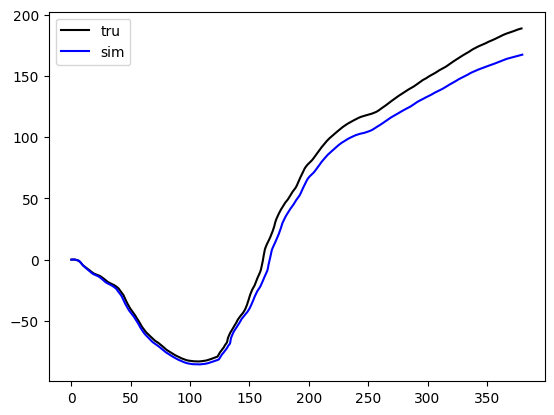

In [57]:
#plot true path vs sim path over time

pathplotter = PathPlotter()
path_array = np.zeros((2,sim,2))
path_array[0] = master.trimmed_og_pos
path_array[1] = master.trimmed_sim_pos
pathplotter.paths(path_array, colors=["black", "blue"],labels=["tru", "sim"])


In [ ]:
#simulation time trial constants
simlen_trial_num = 10
simlen_iters = 10

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_list=(np.arange(simlen_iters)+1)*10000
deltahead=2.4

#running trials!
sim_trial_final_drifts = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_mean_errors = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_rmses = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_errors_over_time = [] #NOT a numpy array. its a 3d one, iter x simlen trial_num x floor(simlen/errorfreq)

for i in range(simlen_iters):
    master.baseline(simlen_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_list[i], deltahead=deltahead)
    sim_trial_final_drifts[i] = master.all_final_drift
    sim_trial_mean_errors[i] = master.all_mean_error
    sim_trial_rmses[i] = master.all_rmse
    sim_trial_errors_over_time.append(master.all_error_over_time)

the mouse moved this far: 400.85624507863236
[[ 73.61503462 394.03877461]]
[ 68.20543432 412.55418129]
the mouse moved this far: 432.95029128523805
[[421.74583437 -97.8591126 ]]
[ 442.67457791 -105.79839836]
the mouse moved this far: 343.2740563099312
[[241.77797498 243.68112063]]
[259.12456243 261.49575733]
the mouse moved this far: 348.51475048976147
[[ 308.46522323 -162.20893122]]
[ 321.48404825 -176.07456517]
the mouse moved this far: 318.6311024115512
[[313.88636611  54.78255741]]
[328.39291042  54.69811977]
the mouse moved this far: 125.21364563006964
[[123.63865597  19.79746958]]
[127.33781703  17.70589827]
the mouse moved this far: 523.0756866427729
[[479.14546282 209.82802343]]
[508.18576285 225.38892082]
the mouse moved this far: 132.19061460162175
[[127.2191913  -35.91150169]]
[133.11254801 -41.38100432]
the mouse moved this far: 253.63676242604652
[[244.31619685 -68.12637676]]
[255.05664923 -80.38391824]
the mouse moved this far: 104.01496033021083
[[101.10482364 -24.432081

In [59]:
print(sim_trial_final_drifts.shape)
print(sim_trial_mean_errors.shape)
print(sim_trial_rmses.shape)
print(f"{len(sim_trial_errors_over_time)}, {len(sim_trial_errors_over_time[0])}, {len(sim_trial_errors_over_time[0][0])}")

(10, 3)
(10, 3)
(10, 3)
10, 3, 10000


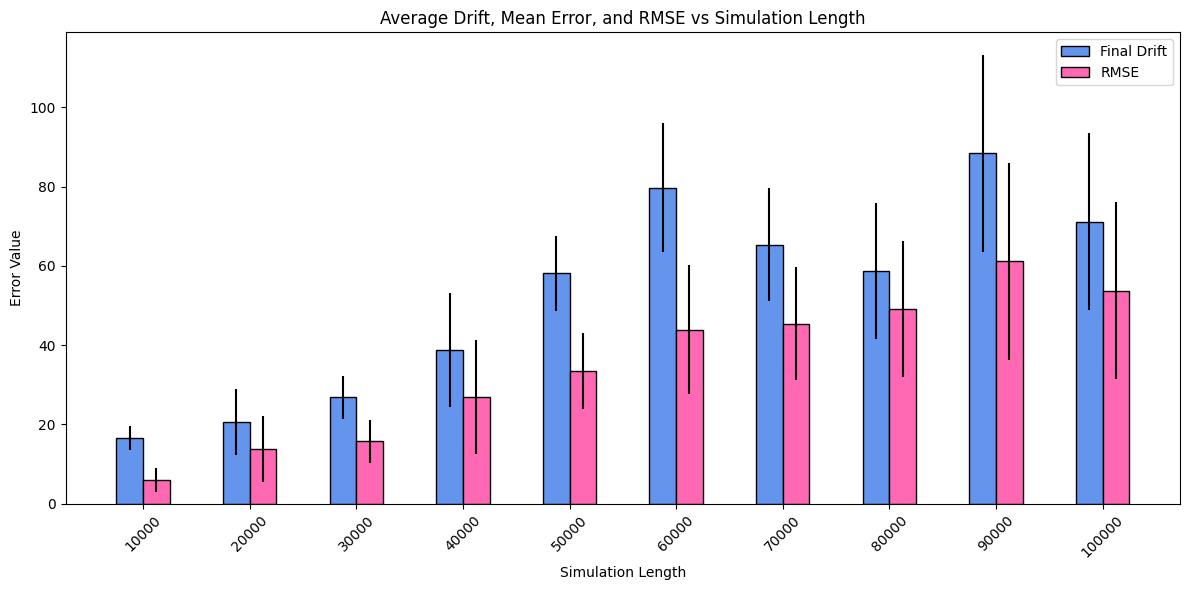

In [28]:
import matplotlib.pyplot as plt
import numpy as np

x_labels = [f"{(i + 1) * 10000}" for i in range(10)]
x_pos = np.arange(len(x_labels))

avg_final_drifts = np.mean(sim_trial_final_drifts, axis=1)
avg_mean_errors = np.mean(sim_trial_mean_errors, axis=1)
avg_rmses = np.mean(sim_trial_rmses, axis=1)

canless_sim_std_final_drifts = np.std(sim_trial_rmses,axis=1)
canless_sim_std_mean_errors = np.std(sim_trial_mean_errors)
canless_sim_std_rmses = np.std(sim_trial_rmses, axis=1)

width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x_pos-width/2, avg_final_drifts, width, label="Final Drift", color="cornflowerblue", yerr=canless_sim_std_final_drifts, edgecolor="black")
#plt.bar(x_pos, avg_mean_errors, width, label="Mean Error", color="mediumpurple", yerr=canless_sim_std_mean_errors, edgecolor="black")
plt.bar(x_pos + width/2, avg_rmses, width, label="RMSE", color="hotpink", yerr=canless_sim_std_rmses,edgecolor="black")

plt.xticks(x_pos, x_labels, rotation=45)
plt.xlabel("Simulation Length")
plt.ylabel("Error Value")
plt.title("Average Drift, Mean Error, and RMSE vs Simulation Length")

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# module number trial . keep range the same from 25 cm to 22.6m
trial_count_per_condition = 10
permutations = np.arange(5, 15)
module_num_spacings = [np.power(2266./25., (1/i)) for i in permutations]

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim = 20000
deltahead=2.4

seeds = [
    'sophie likes 67', 'grid cells are cool', 'schizophrenia', 'sarah', 'sophie is going crazy', 'someone help her', 
    'her synaptic pruning is excessive', 'unlimited games', 'no games', 'unlimited bacon!'
]

assert len(permutations) == len(seeds)

#running trials!

canless_module_num_rmses = np.zeros((len(permutations),trial_count_per_condition))
can_module_num_rmses = np.zeros((len(permutations),trial_count_per_condition))

canless_std_rmses = np.std(canless_module_num_rmses, axis=1)
can_sim_std_rmses = np.std(can_module_num_rmses, axis=1)

for i in range(len(permutations)):
    # no can
    random.seed(seeds[i])  # keeping the seed the same for all permutations gives the same errors across all module numbers
    master.baseline(trial_count_per_condition, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead,
                    NUM_OF_MODS=permutations[i], spacing_min=25,scaling = module_num_spacings[i])
    canless_module_num_rmses[i] = master.all_rmse

    # can
    random.seed(seeds[i])
    master.baseline(trial_count_per_condition, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead,
                    NUM_OF_MODS=permutations[i], spacing_min=25,scaling = module_num_spacings[i])
    can_module_num_rmses[i] = master.all_rmse

the mouse moved this far: 607.0537156466282
[[581.2205321  175.20532738]]
[596.55010298 160.38613943]
the mouse moved this far: 216.84338502853353
[[ 30.52306739 214.68441021]]
[ 44.40394473 225.0761707 ]
the mouse moved this far: 626.2538651227616
[[  38.61780017 -625.06205219]]
[  26.24760232 -624.08588862]
the mouse moved this far: 361.8143334910091
[[357.66148311 -54.66146194]]
[350.22906175 -54.42188072]
the mouse moved this far: 312.2051991273038
[[295.60215884 100.45620962]]
[307.25958373  89.35600165]
the mouse moved this far: 362.34104677337825
[[ 38.29975783 360.31120261]]
[ 44.01276064 372.98357332]
the mouse moved this far: 611.7351352718974
[[  91.1169034  -604.91122129]]
[  96.78878201 -584.7791405 ]
the mouse moved this far: 543.2425603765168
[[-372.2848105  -395.62166179]]
[-367.2432984 -377.835872 ]
the mouse moved this far: 804.3378417387786
[[   1.98456757 -804.33539344]]
[-5.84065684e-01 -7.93003177e+02]
the mouse moved this far: 541.4602546142723
[[253.0331801  478

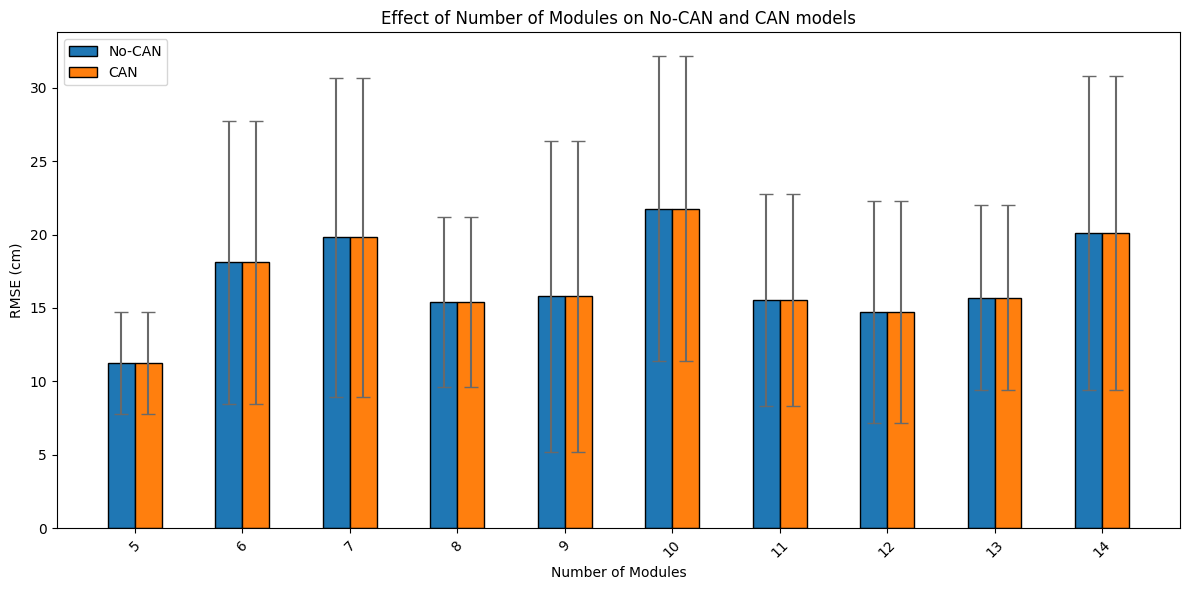

In [13]:
x_labels = permutations
x_pos = np.arange(len(x_labels))

canless_avg_rmses = np.mean(canless_module_num_rmses, axis=1)
can_sim_avg_rmses = np.mean(can_module_num_rmses, axis=1)

canless_std_rmses = np.std(canless_module_num_rmses, axis=1)
can_sim_std_rmses = np.std(can_module_num_rmses, axis=1)
width = 0.25

plt.figure(figsize=(12, 6))

xs = [x_pos - width/2, x_pos + width/2]

for x, rmse, std, label in zip(xs, [canless_avg_rmses, can_sim_avg_rmses], [canless_std_rmses, can_sim_std_rmses], ['No-CAN', 'CAN']):
    plt.bar(x, rmse, width, label=label, edgecolor='black', yerr=std, capsize=5, ecolor='DimGray')
    #yerr=std

plt.title(R"Effect of Number of Modules on No-CAN and CAN models")
plt.xlabel(R"Number of Modules")
plt.ylabel("RMSE (cm)")
plt.xticks(x_pos, x_labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
# module spacing trial..... do tmrw sophie

# parameter = `scaling`

#simulation time trial constants
trial_count_per_condition = 5
permutations = np.arange(1.4, 1.70001, 0.05)

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_length_timesteps = 20_000
deltahead=2.4

seeds = [
    'sophie likes 67', 'grid cells are cool', 'schizophrenia', 'sarah', 'sophie is going crazy',
    'someone help her', 'her synaptic pruning is excessive', 'unlimited games', 'no games', 'unlimited bacon!'
][:7]
assert len(permutations) == len(seeds)

#running trials!
canless_sim_trial_rmses = np.zeros((len(permutations),trial_count_per_condition))
can_sim_trial_rmses = np.zeros((len(permutations),trial_count_per_condition))

for i in range(len(permutations)):
    # no can
    random.seed(seeds[i])
    master.baseline(trial_count_per_condition, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_length_timesteps, deltahead=deltahead, scaling=permutations[i])
    canless_sim_trial_rmses[i] = master.all_rmse
    # can
    random.seed(seeds[i])
    master.baseline(trial_count_per_condition, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_length_timesteps, deltahead=deltahead, scaling=permutations[i])
    can_sim_trial_rmses[i] = master.all_rmse


the mouse moved this far: 607.0537156466282
[[581.2205321  175.20532738]]
[596.55010298 160.38613943]
the mouse moved this far: 216.8433850285335
[[ 30.52306739 214.68441021]]
[ 44.40394473 225.0761707 ]
the mouse moved this far: 626.2538651227616
[[  38.61780017 -625.06205219]]
[  26.24760232 -624.08588862]
the mouse moved this far: 361.8143334910091
[[357.66148311 -54.66146194]]
[350.22906175 -54.42188072]
the mouse moved this far: 312.2051991273038
[[295.60215884 100.45620962]]
[307.25958373  89.35600165]
the mouse moved this far: 607.0537156466282
[[581.2205321  175.20532738]]
[596.55010298 160.38613943]
the mouse moved this far: 216.8433850285335
[[ 30.52306739 214.68441021]]
[ 44.40394473 225.0761707 ]
the mouse moved this far: 626.2538651227616
[[  38.61780017 -625.06205219]]
[  26.24760232 -624.08588862]
the mouse moved this far: 361.8143334910091
[[357.66148311 -54.66146194]]
[350.22906175 -54.42188072]
the mouse moved this far: 312.2051991273038
[[295.60215884 100.45620962]]


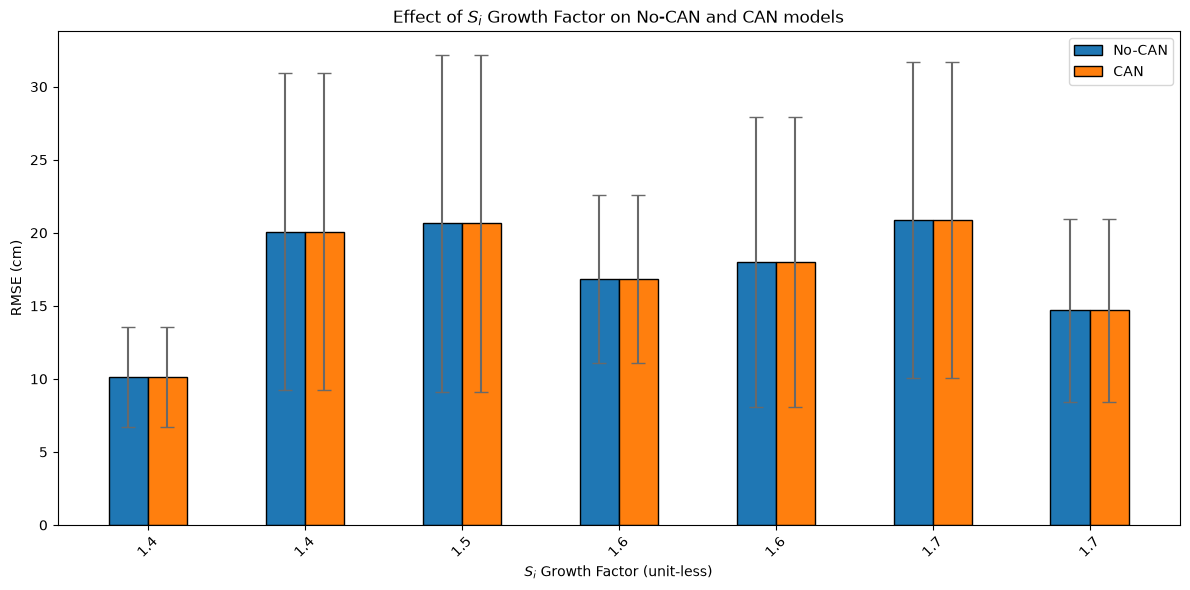

In [4]:
x_labels = [f'{perm:.1f}' for perm in permutations]
x_pos = np.arange(len(x_labels))

canless_avg_rmses = np.mean(canless_sim_trial_rmses, axis=1)
can_sim_avg_rmses = np.mean(can_sim_trial_rmses, axis=1)

canless_std_rmses = np.std(canless_sim_trial_rmses, axis=1)
can_sim_std_rmses = np.std(can_sim_trial_rmses, axis=1)
width = 0.25

plt.figure(figsize=(12, 6))

xs = [x_pos - width/2, x_pos + width/2]

for x, rmse, std, label in zip(xs, [canless_avg_rmses, can_sim_avg_rmses], [canless_std_rmses, can_sim_std_rmses], ['No-CAN', 'CAN']):
    plt.bar(x, rmse, width, label=label, edgecolor='black', yerr=std, capsize=5, ecolor='DimGray')

plt.title(R"Effect of ${S_i}$ Growth Factor on No-CAN and CAN models")
plt.xlabel(R"${S_i}$ Growth Factor (unit-less)")
plt.ylabel("RMSE (cm)")
plt.xticks(x_pos, x_labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()